<a href="https://colab.research.google.com/github/raaghavkk/UG04-NLP-COMM061/blob/main/notebooks/raaghav_data_analysisUG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UG04 — Data Analysis & Visualisation
**COMM061 NLP Coursework | Raaghav Kulshreshtha | 6776090**

## 1. Load Dataset

In [28]:
# Install required libraries
!pip install datasets

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

In [30]:
ds = load_dataset("surrey-nlp/BESSTIE-CW-26")
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 3747
    })
    validation: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 313
    })
    test: Dataset({
        features: ['text', 'variety', 'source', 'Sentiment', 'Sarcasm'],
        num_rows: 2183
    })
})


In [31]:
df_train = pd.DataFrame(ds['train'])
df_val = pd.DataFrame(ds['validation'])
df_test = pd.DataFrame(ds['test'])

print(df_train.head())
print(df_train.columns.tolist())

                                                text variety  source  \
0  I'm a member of the Green Party but I'll be vo...   en-UK  Reddit   
1  Yeah it blew out to 3x what it was budgeted fo...   en-AU  Reddit   
2  Food was pretty great. A little dry, but I am ...   en-AU  Google   
3  Firstly the staff seemed as if they did n't wa...   en-UK  Google   
4  We came for lunch and enjoyed the food we orde...   en-UK  Google   

   Sentiment  Sarcasm  
0        0.0      0.0  
1        0.0      1.0  
2        1.0      0.0  
3        0.0      0.0  
4        1.0      0.0  
['text', 'variety', 'source', 'Sentiment', 'Sarcasm']


## 2. Dataset Statistics

In [32]:
df_au = df_train[df_train['variety'] == 'en-AU'].reset_index(drop=True)
df_in = df_train[df_train['variety'] == 'en-IN'].reset_index(drop=True)
df_uk = df_train[df_train['variety'] == 'en-UK'].reset_index(drop=True)

In [33]:
print("Training set shape:", df_train.shape)
print("Validation set shape:", df_val.shape)
print("Test set shape:", df_test.shape)

print("\nVariety counts (train):")
print(df_train['variety'].value_counts())

print("\nSource counts (train):")
print(df_train['source'].value_counts())

Training set shape: (3747, 5)
Validation set shape: (313, 5)
Test set shape: (2183, 5)

Variety counts (train):
variety
en-IN    1399
en-UK    1203
en-AU    1145
Name: count, dtype: int64

Source counts (train):
source
Google    1874
Reddit    1873
Name: count, dtype: int64


## 3. Label Distribution Visualisation (Q1.1)

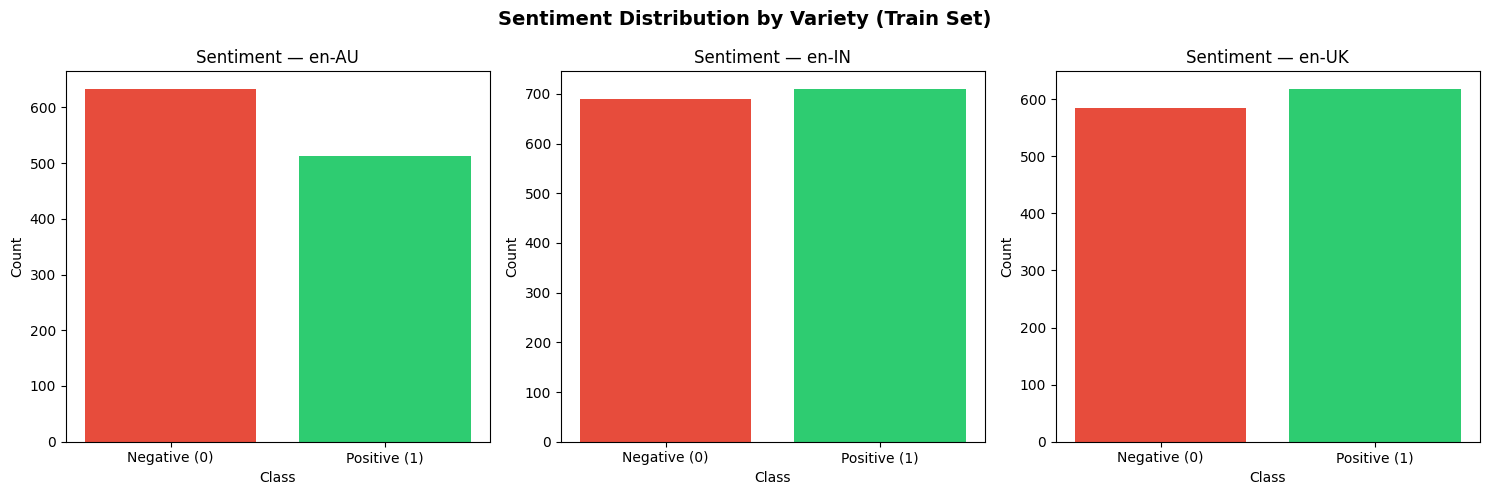

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

varieties = ['en-AU', 'en-IN', 'en-UK']
for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sentiment'].value_counts().sort_index()
    axes[i].bar(['Negative (0)', 'Positive (1)'], counts.values, color=['#e74c3c', '#2ecc71'])
    axes[i].set_title(f'Sentiment — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sentiment Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sentiment_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

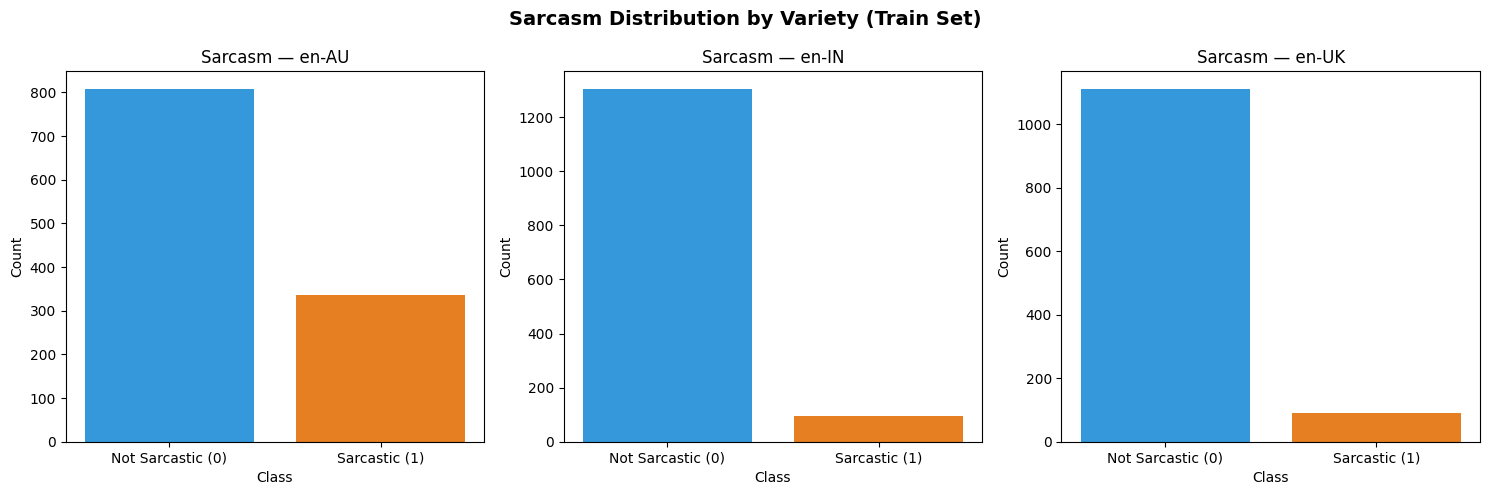

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, variety in enumerate(varieties):
    subset = df_train[df_train['variety'] == variety]
    counts = subset['Sarcasm'].value_counts().sort_index()
    axes[i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Sarcasm — {variety}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sarcasm Distribution by Variety (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarcasm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

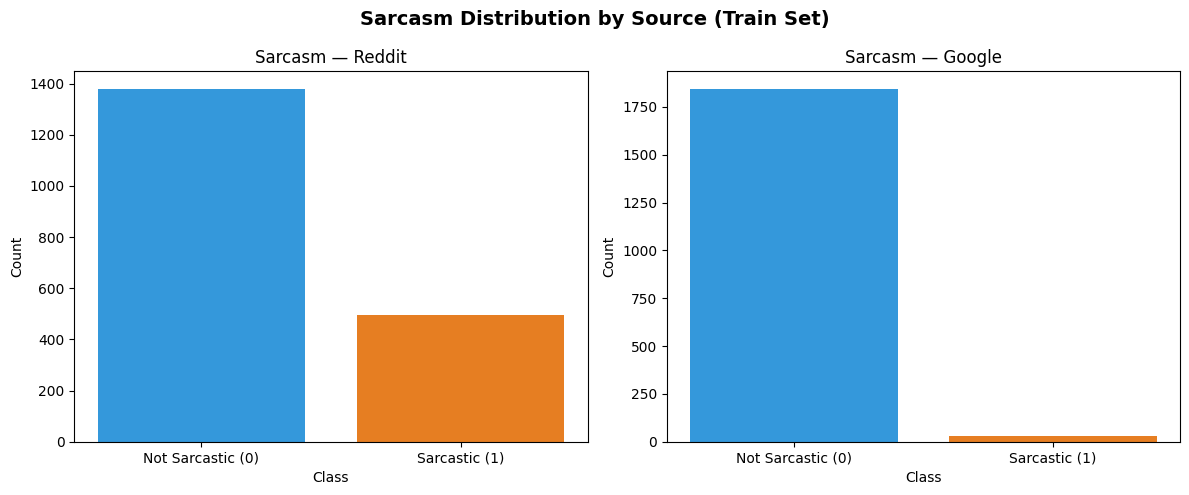

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sources = ['Reddit', 'Google']
for i, source in enumerate(sources):
    subset = df_train[df_train['source'] == source]
    counts = subset['Sarcasm'].value_counts().sort_index()
    axes[i].bar(['Not Sarcastic (0)', 'Sarcastic (1)'], counts.values, color=['#3498db', '#e67e22'])
    axes[i].set_title(f'Sarcasm — {source}')
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Class')

plt.suptitle('Sarcasm Distribution by Source (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sarcasm_by_source.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Vocabulary Analysis (Q1.2)
### 4.1 Slang & Unique Vocabulary per Variety

In [37]:
!pip install wordcloud

Unique words — en-AU: 3334, en-IN: 3207, en-UK: 2797


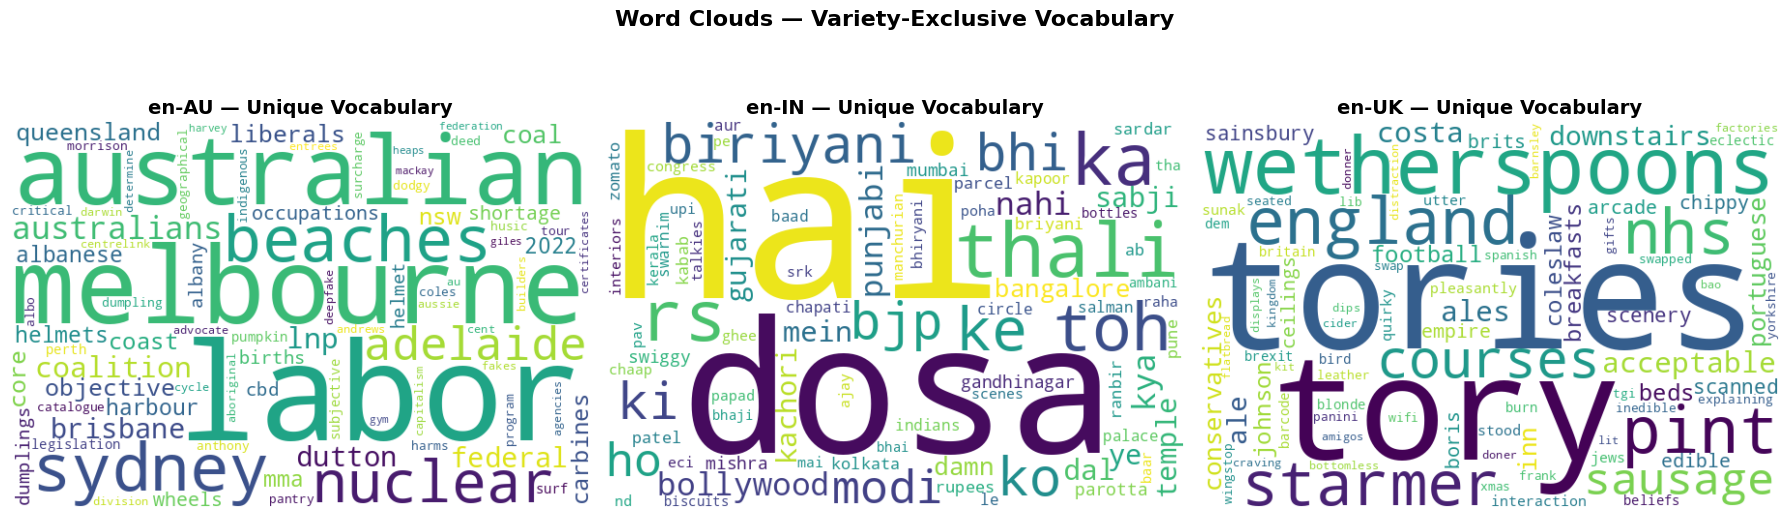

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

varieties = ['en-AU', 'en-IN', 'en-UK']
dfs = [df_au, df_in, df_uk]

def get_vocab_counts(df):
    vectorizer = CountVectorizer(stop_words='english', max_features=10000)
    vectorizer.fit(df['text'])
    counts = dict(zip(vectorizer.get_feature_names_out(),
                      vectorizer.transform(df['text']).toarray().sum(axis=0)))
    return counts

counts_au = get_vocab_counts(df_au)
counts_in = get_vocab_counts(df_in)
counts_uk = get_vocab_counts(df_uk)

def get_unique_words(target_counts, other_counts_list):
    # Keep words that only appear in target variety
    other_words = set()
    for other in other_counts_list:
        other_words.update(other.keys())
    return {k: v for k, v in target_counts.items() if k not in other_words}

unique_au = get_unique_words(counts_au, [counts_in, counts_uk])
unique_in = get_unique_words(counts_in, [counts_au, counts_uk])
unique_uk = get_unique_words(counts_uk, [counts_au, counts_in])

print(f"Unique words — en-AU: {len(unique_au)}, en-IN: {len(unique_in)}, en-UK: {len(unique_uk)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (variety, unique_words) in zip(axes, [
    ('en-AU', unique_au),
    ('en-IN', unique_in),
    ('en-UK', unique_uk)
]):
    wc = WordCloud(width=600, height=400, background_color='white',
                   max_words=80, colormap='viridis').generate_from_frequencies(unique_words)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{variety} — Unique Vocabulary', fontsize=14, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds — Variety-Exclusive Vocabulary', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Top 10 unique words per variety
print("Top 10 unique words — en-AU:")
au_top = sorted(unique_au.items(), key=lambda x: x[1], reverse=True)[:10]
for word, count in au_top:
    print(f"  {word}: {count}")

print("\nTop 10 unique words — en-IN:")
in_top = sorted(unique_in.items(), key=lambda x: x[1], reverse=True)[:10]
for word, count in in_top:
    print(f"  {word}: {count}")

print("\nTop 10 unique words — en-UK:")
uk_top = sorted(unique_uk.items(), key=lambda x: x[1], reverse=True)[:10]
for word, count in uk_top:
    print(f"  {word}: {count}")

Top 10 unique words — en-AU:
  labor: 47
  melbourne: 37
  australian: 30
  sydney: 29
  beaches: 27
  nuclear: 22
  adelaide: 20
  australians: 19
  coalition: 15
  lnp: 15

Top 10 unique words — en-IN:
  hai: 54
  dosa: 35
  thali: 32
  ka: 29
  rs: 28
  toh: 24
  ke: 20
  biriyani: 18
  ko: 18
  bhi: 17

Top 10 unique words — en-UK:
  tories: 18
  tory: 16
  wetherspoons: 16
  england: 13
  pint: 13
  nhs: 12
  starmer: 12
  courses: 11
  sausage: 11
  acceptable: 10


In [40]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

# Slang terms from each variety
slang_terms = {
    'en-AU': ['arvo', 'ute', 'onya', 'reckon', 'maccas'],
    'en-IN': ['biryani', 'chowkidar', 'yaar', 'jugaad', 'timepass'],
    'en-UK': ['wetherspoons', 'innit', 'dodgy', 'chuffed', 'gobsmacked']
}

print("=== Tokenization Analysis of Slang Terms ===\n")
for variety, terms in slang_terms.items():
    print(f"{variety}:")
    for term in terms:
        tokens = tokenizer.tokenize(term)
        print(f"  '{term}' → {tokens} ({len(tokens)} tokens)")
    print()

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

=== Tokenization Analysis of Slang Terms ===

en-AU:
  'arvo' → ['ar', 'vo'] (2 tokens)
  'ute' → ['ute'] (1 tokens)
  'onya' → ['ony', 'a'] (2 tokens)
  'reckon' → ['reck', 'on'] (2 tokens)
  'maccas' → ['m', 'acc', 'as'] (3 tokens)

en-IN:
  'biryani' → ['b', 'iry', 'ani'] (3 tokens)
  'chowkidar' → ['ch', 'ow', 'kid', 'ar'] (4 tokens)
  'yaar' → ['ya', 'ar'] (2 tokens)
  'jugaad' → ['j', 'uga', 'ad'] (3 tokens)
  'timepass' → ['time', 'pass'] (2 tokens)

en-UK:
  'wetherspoons' → ['w', 'ether', 'sp', 'oons'] (4 tokens)
  'innit' → ['inn', 'it'] (2 tokens)
  'dodgy' → ['d', 'od', 'gy'] (3 tokens)
  'chuffed' → ['ch', 'uffed'] (2 tokens)
  'gobsmacked' → ['gob', 'sm', 'acked'] (3 tokens)



### 4.2 Tokenization Analysis

The tokenization results are pretty telling. RoBERTa has basically never seen any of
these slang terms before so it just breaks them into random subword chunks that mean
nothing. "maccas" becomes ['m', 'acc', 'as'], "wetherspoons" becomes ['w', 'ether',
'sp', 'oons']. The model is essentially trying to read a word it's never seen by
sounding out the letters, like a kid reading a book above their level.

The en-IN results are where it gets really interesting though. "chowkidar" splits into
4 meaningless tokens and that's kind of expected for a culturally specific term. But
what's more revealing is that several of the most frequent unique en-IN words aren't
even slang, they're Hindi function words like "hai", "ka", "ke", "toh", "bhi" that just
naturally appear in everyday Indian English sentences. This is code-switching and it's
genuinely unique to the Indian context in a way that doesn't really have an equivalent
in AU or UK English.

In India the line between Hindi and English has been blurring for so long that it's not
even considered switching anymore, it's just how people talk. Think about how in any
Shah Rukh Khan interview or literally any Bollywood dialogue you'll hear sentences that
are half English half Hindi without anyone batting an eye. "Yaar this place is good na?"
is a completely normal sentence. RoBERTa has no framework for this at all because it
was trained on text where English is English and nothing else bleeds in.

This matters a lot for sarcasm detection specifically because a lot of Indian sarcasm
lives in that in-between space. The punchline of a joke might depend on a Hindi word
mid-sentence carrying a specific cultural weight that the model just sees as a broken
token it can't make sense of. A really good example of this is phonetic substitution
sarcasm, where a Hindi word is chosen because it sounds like an English word with a
completely different meaning. The recent Bollywood film Dhurandhar uses this perfectly
with "batakh" (Hindi for duck) — a sentence like "sir your batakhs are really white"
looks completely innocent on paper but is implying something about buttocks purely
through phonetic similarity. RoBERTa sees the word "batakh", has no idea what it means,
fragments it into meaningless tokens, and misses the sarcastic intent entirely. This
kind of phonetic substitution humour is deeply embedded in how Indian English speakers
communicate online, especially on Reddit, and it represents an entire layer of sarcasm
that a model pretrained on standard English text has absolutely no way of picking up on.